In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [6]:
def getCSV(csv):
    dfl = pd.read_csv(csv)
    return dfl
dfl = getCSV(r"C:\Users\Tom\OneDrive\Documents\APROJECTS\DiscriminationEthnicity.csv")
print(dfl)

                                      Statistic Label  Year  \
0   Individuals who experienced discrimination in ...  2024   
1   Individuals who experienced discrimination in ...  2024   
2   Individuals who experienced discrimination in ...  2024   
3   Individuals who experienced discrimination in ...  2024   
4   Individuals who experienced discrimination in ...  2024   
..                                                ...   ...   
91  Individuals who experienced discrimination in ...  2024   
92  Individuals who experienced discrimination in ...  2024   
93  Individuals who experienced discrimination in ...  2024   
94  Individuals who experienced discrimination in ...  2024   
95  Individuals who experienced discrimination in ...  2024   

                 Setting of Discrimination in Housing  \
0                   Looking for housing/accommodation   
1                   Looking for housing/accommodation   
2                   Looking for housing/accommodation   
3              

In [19]:
def changeNames(name):
    switch = {
        "Black Irish/black African/other black background": "Black",
        'Black or Black Irish - African': 'Black \nAfrican',
        'Asian Irish/Asian Indian/Chinese/other Asian background': 'Asian',
        'Asian or Asian Irish - Chinese': 'Chinese',
        'Asian or Asian Irish - any other Asian background': 'Other \nAsian',
        'Other white ethnic backgrounds': 'White \nOther',
        'Irish Travellers/Roma': 'Travellers\nRoma',
        'Other ethnic backgrounds': 'Other ethnic \nbackgrounds'
    }
    if name not in switch:
        return name 
    else:
        return switch[name]

In [20]:
label='Looking for housing/accommodation'
filtered_df = dfl[(dfl['Setting of Discrimination in Housing']==label)&(dfl['Experienced discrimination in housing']=='Yes')&(dfl['Ethnicity']!='All ethnicities')]
filtered_df['Ethnicity'] = filtered_df['Ethnicity'].apply(changeNames)

                                     Statistic Label  Year  \
1  Individuals who experienced discrimination in ...  2024   
2  Individuals who experienced discrimination in ...  2024   
3  Individuals who experienced discrimination in ...  2024   
4  Individuals who experienced discrimination in ...  2024   
5  Individuals who experienced discrimination in ...  2024   
6  Individuals who experienced discrimination in ...  2024   
7  Individuals who experienced discrimination in ...  2024   

  Setting of Discrimination in Housing Experienced discrimination in housing  \
1    Looking for housing/accommodation                                   Yes   
2    Looking for housing/accommodation                                   Yes   
3    Looking for housing/accommodation                                   Yes   
4    Looking for housing/accommodation                                   Yes   
5    Looking for housing/accommodation                                   Yes   
6    Looking for housin

C:\Users\Tom\AppData\Local\Temp\ipykernel_18348\1826282320.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df['Ethnicity'] = filtered_df['Ethnicity'].apply(changeNames)


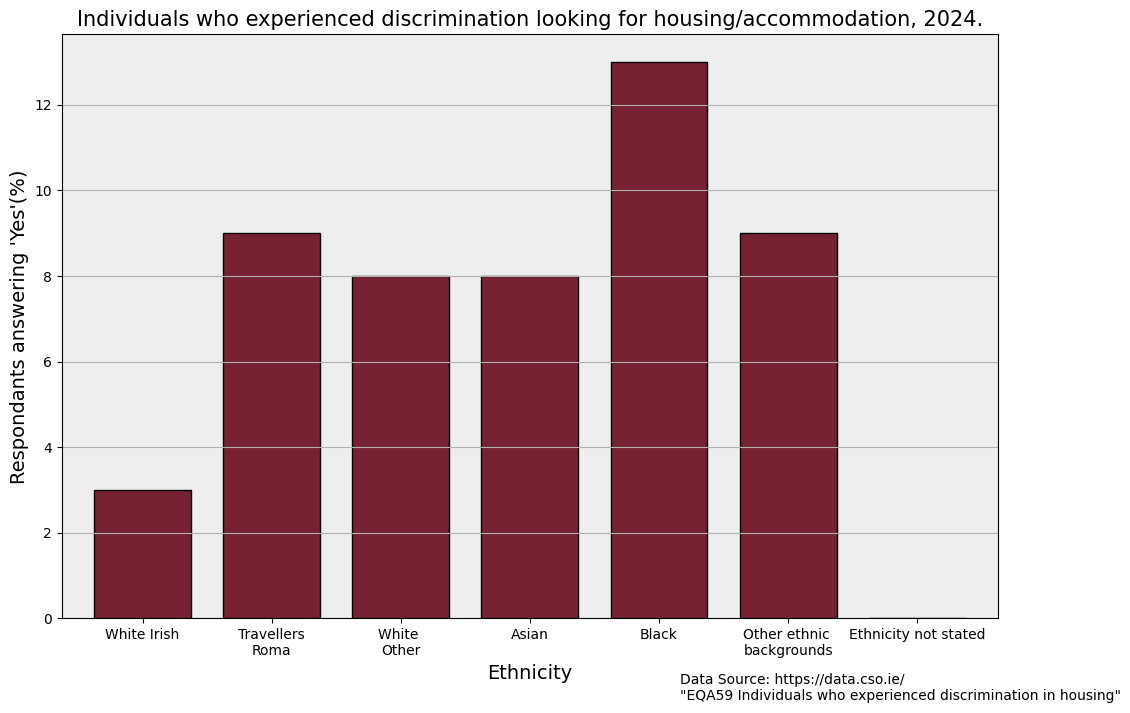

In [23]:
fig, ax = plt.subplots(1, 1, figsize=(13, 8))

filtered_df.plot(x="Ethnicity", y="VALUE", kind="bar", width=0.75, edgecolor="black", color="#723", ax=ax)

title_string = "Individuals who experienced discrimination "+label.lower()+", 2024."

plt.title(title_string, fontsize=15)
plt.xlabel('Ethnicity', fontsize=14)
plt.ylabel('Respondants answering \'Yes\'(%)', fontsize=14)
plt.xticks(rotation=0) 
#ax.set_xlim(200,550)
ax.set_facecolor('#EEEEEE') 
#ax.legend(percentage_df['Towns'].tolist(), percentage_df['VALUE'].tolist())
ax.get_legend().remove()
plt.grid(True, axis="y")

plt.subplots_adjust(left=0.2, right=0.92, top=0.9, bottom=0.17)
plt.text(0.66, -0.14, "Data Source: https://data.cso.ie/ \n\"EQA59 Individuals who experienced discrimination in housing\"", ha='left', transform=ax.transAxes)

save_fig = 'Discrimination-lookingHousing.png'
plt.savefig(save_fig)

# Show the plot
plt.show()
